# FLIM / confocal image processing for fluorescence lifetime reconstruction

This notebook demonstrates FLIM image reconstruction with `brighteyes_flim.calibrate_h5_file()`. The goal is to show that calibration can be performed without using the legacy reference channel (channel 26), which is no longer available in recent BrightEyes-MCS firmware versions.

The Lamina/Tubulin dataset was previously analyzed and published within the S2ISM framework:
https://github.com/VicidominiLab/s2ISM/blob/main/examples/Reconstruction_lifetime.ipynb

Here, we reproduce comparable results using the phasor analysis tools provided by BrightEyes-FLIM, while intentionally excluding the reference channel from the calibration step.

The experimental dataset is available at:
https://doi.org/10.5281/zenodo.11284051
The raw Lamina/Tubulin data were acquired with a laser repetition rate of 41.48 MHz (period 24.107 ns) and 81 time bins, corresponding to a bin width of 0.297619 ns.


## Imports
Import the libraries needed to process the FLIM dataset, both for the acquired sample and for the IRF reference. The data layout is `(Nx, Ny, time bin, detector channel)`.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs
from scipy.ndimage import shift
from skimage.registration import phase_cross_correlation
from brighteyes_flim import calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts



## Calibrate the sample and reference datasets

In [19]:
TAU_REF = 2.5  # Let the algorithm estimate the reference lifetime directly from the reference data.
# CHANNEL_SKEW_SOURCE = np.array(custom_skew_bins, dtype=float)
# If a custom skew array is used, its length must match the calibrated channel count.
OVERWRITE = True

# The Lamina/Tubulin dataset uses 81 bins at 0.297619 ns,
# corresponding to about 41.48 MHz and a 24.107 ns laser period.
# These files were acquired with an older BrightEyes-MCS version,
# so the laser timing must be provided explicitly.
# Newer BrightEyes-MCS files store this information in the HDF5 metadata,
# so in that case `LASER_PERIOD_NS = None` is usually sufficient.

LASER_FREQ_MHZ = None #41.48
LASER_PERIOD_NS = None #1e3 / LASER_FREQ_MHZ

FILE_REFERENCE = r"/mnt/DATA/Mixed Data/TestGiuse/FLIMLabs_DFD.h5"
FILE_DATA = r"/mnt/DATA/Mixed Data/TestGiuse/Coumarine_DFD.h5"

DATA_KEY = ("data", "data_channels_extra")

# If DATA_KEY includes multiple HDF5 datasets, choose which one to inspect below.
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]

FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type="ref",
    tau_ref=TAU_REF,
    fit_mode="model_shift",
    fit_type="likelihood",
    channel_skew_type="phase_cross_correlation",
    channel_skew_source="irf",
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=True,
)

Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/APR_lib.py:130: UserWarning: Could not determine RMS error between images with the normalized average intensities np.float64(9.062713347497267) and np.float64(0.0). Either the reference or moving image may be empty.
  shift_vec[i, :], error[i, :], diffphase = phase_cross_correlation(dsetW[:, :, ref], dsetW[:, :, i],


## Inspect the calibrated HDF5 file

In [20]:
# show_h5_structure_html(FILE_WITH_CALIBRATION)  # Disabled here to keep the notebook output compact.


## Load the calibrated data and realign detector channels
Load the calibrated dataset, apply `channel_skew` to realign the detector channels, and then sum the signal across the channel axis.


In [22]:
def centroid(data):
    x = np.arange(data.size)
    idx = np.sum(x*data)/data.sum()
    return idx

def clean_irf(irf, threshold = 0.3, window = 6):
    
    time = np.arange(irf.size)
    
    t_irf = np.where(irf>threshold, irf, 0)
    
    t0 = centroid(t_irf)
    
    indices = np.argwhere(np.logical_and(time > t0 - window, time < t0 + window))
    
    final_irf = np.zeros_like(irf)
    
    final_irf[indices] = irf[indices]
    
    return final_irf

In [36]:
with h5py.File(FILE_WITH_CALIBRATION,"r") as f:
    
        laser_freq_mhz = float(f["calibration/data"].attrs["laser_freq_in_mhz"]) 
        laser_period_ns = float(f["calibration/data"].attrs["laser_period_in_ns"])
        rangex = f['configurationGUI'].attrs['range_x']
        nx = f['configurationGUI'].attrs['nx']
        pixel_size_x_um= rangex / nx
        nbin = f['configurationGUI'].attrs['timebin_per_pixel']
        dt = f['configurationGUI'].attrs['time_resolution']
        pxdwelltime = dt * nbin

        print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")
    
        print(f.keys())
        data_input = f["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference.
        channel_skew = f["calibration/data/channel_skew"][:]
        common_delay_in_bins = f["calibration/data/common_delay_in_bins"][:]
        irf_common_delay_realigned = f["calibration/data/irf_common_delay_realigned"][:]   

        irf_common_delay_realigned_clean=np.empty_like(irf_common_delay_realigned)
        for i in range(irf_common_delay_realigned.shape[-1]): 
                d=irf_common_delay_realigned[:,i]    
                d=d/d.max()
                k = clean_irf(d, threshold = 0.3, window = 2/(laser_period_ns/nbin))
                irf_common_delay_realigned_clean[:,i]=k
        
        irf_common_delay_realigned = irf_common_delay_realigned_clean

        print(data_input.shape)
        data_summed_no_alignment = np.sum(data_input,axis=(0,1,2,3,5))
        irf_summed_no_alignment = irf_common_delay_realigned.sum(axis=-1)
        irf_summed_no_alignment = irf_summed_no_alignment / irf_summed_no_alignment.sum()

        data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0,...]
        irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
        irf_summed = irf_summed / irf_summed.sum()

        data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0,...]
        irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)
        irf_summed_rev = irf_summed_rev / irf_summed_rev.sum()



        print(data_summed.shape)
        print(irf_summed.shape)
        print("Channel skew correction applied.")



        x_dim, y_dim = data_summed.shape[0], data_summed.shape[1]
        h5_dim = (x_dim, y_dim)
        # h5_dataset_phasor_pix = fil.create_dataset('h5_dataset_phasor_pix', shape=h5_dim, dtype=np.complex128)
        print("Calculating phasor for each pixel...")
        h5_dataset_phasor_pix = flim.calculate_phasor(data_summed[:, :, :],
                                                        harmonic=1)
        irf_phasor=flim.calculate_phasor(irf_summed,threshold=0,harmonic=1)
        print("Phasor calculation completed.")
        print(h5_dataset_phasor_pix.shape)
        print("Freeing memory...")
        del data_input




Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra', 'thumbnail']>
(1, 1, 512, 512, 91, 25)
(512, 512, 91)
(91,)
Channel skew correction applied.
Calculating phasor for each pixel...
Phasor calculation completed.
(512, 512)
Freeing memory...


## Compare the effect of channel-skew correction

The plots below show the summed IRF and the summed sample signal after channel realignment.

For comparison, the same `channel_skew` values are also applied in the reverse direction.
Only the forward correction improves the temporal alignment, as expected.


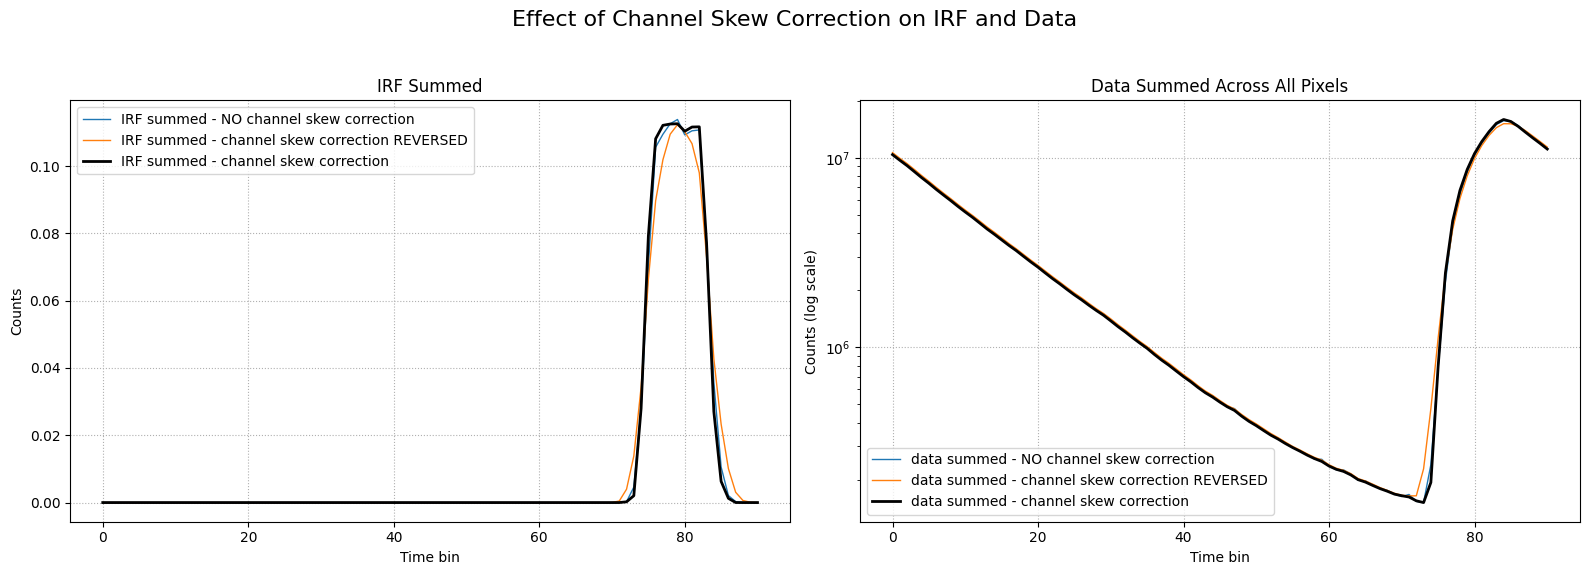

In [37]:
# Compare the summed IRF and data traces before and after channel-skew correction.
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Effect of Channel Skew Correction on IRF and Data", fontsize=16)

# Left panel: IRF traces.
axs[0].plot(irf_summed_no_alignment, label="IRF summed - NO channel skew correction", color='tab:blue', linewidth=1)
axs[0].plot(irf_summed_rev, label="IRF summed - channel skew correction REVERSED", color='tab:orange', linestyle='-', linewidth=1)
axs[0].plot(irf_summed, label="IRF summed - channel skew correction", color='k', linestyle='-', linewidth=2)
axs[0].set_title("IRF Summed")
axs[0].set_xlabel("Time bin")
axs[0].set_ylabel("Counts")
axs[0].legend()
axs[0].grid(True, linestyle=':')

# Right panel: sample data summed over all pixels.
axs[1].plot(data_summed_no_alignment, label="data summed - NO channel skew correction", color='tab:blue', linewidth=1)
axs[1].plot(data_summed_rev.sum(axis=(0,1)), label ="data summed - channel skew correction REVERSED", color='tab:orange', linestyle='-', linewidth=1)
axs[1].plot(data_summed.sum(axis=(0,1)), label ="data summed - channel skew correction", color='k', linestyle='-', linewidth=2)
axs[1].set_title("Data Summed Across All Pixels")
axs[1].set_xlabel("Time bin")
axs[1].set_ylabel("Counts (log scale)")
axs[1].set_yscale("log")
axs[1].legend()
axs[1].grid(True, linestyle=':')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [38]:
irf_phasor

np.complex128(0.6655359116948265-0.7228810269831417j)

## Compute intensity, phasor, and lifetime maps
Use the realigned histograms to derive the confocal intensity map, normalize the IRF phasor, and compute the corrected phasor and lifetime maps.


In [39]:
intensity_map = data_summed.sum(axis=-1)                # Confocal intensity image.



In [40]:
#irf_phasor_norm = irf_phasor/abs(irf_phasor)            # Normalize the IRF phasor to unit magnitude.
irf_phasor_norm = irf_phasor
phasor_map = h5_dataset_phasor_pix / irf_phasor_norm    # Correct the sample phasor using the IRF phasor.


In [41]:
phasor_map

array([[0.50120179+0.49378123j, 0.46552569+0.53082938j,
        0.46755445+0.49929103j, ..., 0.48998302+0.52079316j,
        0.46919702+0.51369635j, 0.46575971+0.49660826j],
       [0.46280196+0.51104604j, 0.46399458+0.53090619j,
        0.50693152+0.49998104j, ..., 0.45338335+0.51045921j,
        0.48088612+0.49925233j, 0.44521997+0.51897424j],
       [0.46190912+0.51168368j, 0.46730714+0.51052169j,
        0.49682252+0.52277343j, ..., 0.46404992+0.49978825j,
        0.51296457+0.50235949j, 0.46715212+0.50490263j],
       ...,
       [0.47709184+0.52641666j, 0.45449035+0.49947141j,
        0.50308996+0.51403503j, ..., 0.5016547 +0.5051113j ,
        0.48416721+0.50432206j, 0.4645891 +0.50806471j],
       [0.4790294 +0.50235288j, 0.47877545+0.49247485j,
        0.47489962+0.52021188j, ..., 0.47180772+0.51315151j,
        0.51172252+0.52059726j, 0.44279608+0.51351167j],
       [0.47874614+0.51018395j, 0.42506571+0.52866891j,
        0.44293474+0.49613634j, ..., 0.46676103+0.53967265j,
 

In [42]:
abs(irf_phasor_norm)

np.float64(0.9825960660045742)

In [43]:
# Apply an intensity threshold to suppress low-signal pixels in the plots.

threshold = 0.05
thresholded_phasor_map = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
tau_m_map = flim.calculate_tau_m(phasor_map, dfd_freq=laser_freq_mhz) * 1e3 # ns
tau_phi_map = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz) * 1e3 # ns

thresholded_tau_m_map = flim.calculate_tau_m(thresholded_phasor_map, dfd_freq=laser_freq_mhz) * 1e3
thresholded_tau_phi_map = flim.calculate_tau_phi(thresholded_phasor_map, dfd_freq=laser_freq_mhz) * 1e3
thresholded_tau_m_map = thresholded_tau_m_map[np.isfinite(thresholded_tau_m_map)]
thresholded_tau_phi_map = thresholded_tau_phi_map[np.isfinite(thresholded_tau_phi_map)]

# Keep the existing tau_m names for the cells below.
lifetime_map = tau_m_map
thresholded_tau_map = thresholded_tau_m_map


In [44]:
tau_m_map

array([[4.01867731, 3.9908761 , 4.24308157, ..., 3.88987549, 4.10805659,
        4.28030621],
       [4.18008391, 4.00159929, 3.92386311, ..., 4.25822569, 4.13716111,
        4.24601074],
       [4.18153806, 4.14957839, 3.82182347, ..., 4.2667435 , 3.85740013,
        4.19853179],
       ...,
       [3.94140089, 4.34558384, 3.84326324, ..., 3.92516426, 4.06935819,
        4.19167452],
       [4.12621127, 4.21034303, 4.00962931, ..., 4.09248434, 3.72527548,
        4.31306143],
       [4.06344367, 4.30951139, 4.46750061, ..., 3.9070081 , 4.15776981,
        4.09000643]], shape=(512, 512))

## Compare tau_m and tau_phi
Compute summary statistics on the same thresholded pixels and overlay the two phasor lifetime estimators.

n_pixels: 262144
tau_m_mean_ns: 4.1219
tau_phi_mean_ns: 4.2493
tau_phi_minus_tau_m_mean_ns: 0.1274
tau_m_weighted_mean_ns: 4.1207
tau_phi_weighted_mean_ns: 4.2512
tau_phi_minus_tau_m_weighted_mean_ns: 0.1304
tau_m_std_ns: 0.1565
tau_phi_std_ns: 0.2026


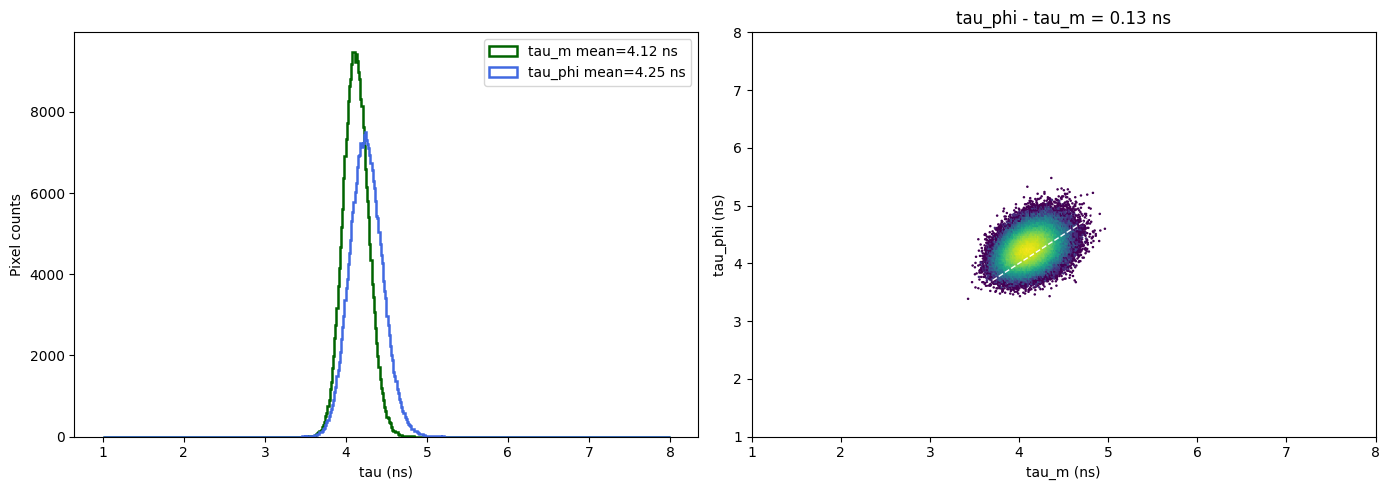

In [45]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare
tau_compare_weights = intensity_map[tau_compare_mask]
comparison_lower_bound = 1.0
comparison_upper_bound = 8.0
comparison_bins = 500

tau_compare_summary = {
    "n_pixels": int(tau_m_compare.size),
    "tau_m_mean_ns": float(np.nanmean(tau_m_compare)),
    "tau_phi_mean_ns": float(np.nanmean(tau_phi_compare)),
    "tau_phi_minus_tau_m_mean_ns": float(np.nanmean(tau_diff_compare)),
    "tau_m_weighted_mean_ns": float(np.average(tau_m_compare, weights=tau_compare_weights)),
    "tau_phi_weighted_mean_ns": float(np.average(tau_phi_compare, weights=tau_compare_weights)),
    "tau_phi_minus_tau_m_weighted_mean_ns": float(np.average(tau_diff_compare, weights=tau_compare_weights)),
    "tau_m_std_ns": float(np.nanstd(tau_m_compare)),
    "tau_phi_std_ns": float(np.nanstd(tau_phi_compare)),
}
for key, value in tau_compare_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

fig, (ax_hist, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))

ax_hist.hist(
    tau_m_compare,
    bins=comparison_bins,
    range=(comparison_lower_bound, comparison_upper_bound),
    histtype="step",
    linewidth=1.8,
    color="darkgreen",
    label=f"tau_m mean={tau_compare_summary['tau_m_mean_ns']:.2f} ns",
)
ax_hist.hist(
    tau_phi_compare,
    bins=comparison_bins,
    range=(comparison_lower_bound, comparison_upper_bound),
    histtype="step",
    linewidth=1.8,
    color="royalblue",
    label=f"tau_phi mean={tau_compare_summary['tau_phi_mean_ns']:.2f} ns",
)
ax_hist.set_xlabel("tau (ns)")
ax_hist.set_ylabel("Pixel counts")
ax_hist.legend()

ax_scatter.hexbin(tau_m_compare, tau_phi_compare, gridsize=120, bins="log", cmap="viridis")
lims = [comparison_lower_bound, comparison_upper_bound]
ax_scatter.plot(lims, lims, color="white", linestyle="--", linewidth=1)
ax_scatter.set_xlim(lims)
ax_scatter.set_ylim(lims)
ax_scatter.set_xlabel("tau_m (ns)")
ax_scatter.set_ylabel("tau_phi (ns)")
ax_scatter.set_title(f"tau_phi - tau_m = {tau_compare_summary['tau_phi_minus_tau_m_mean_ns']:.2f} ns")

fig.tight_layout()


## Visualize the FLIM reconstruction
Display the confocal intensity, lifetime map, phasor plot, and lifetime histogram for the realigned dataset.


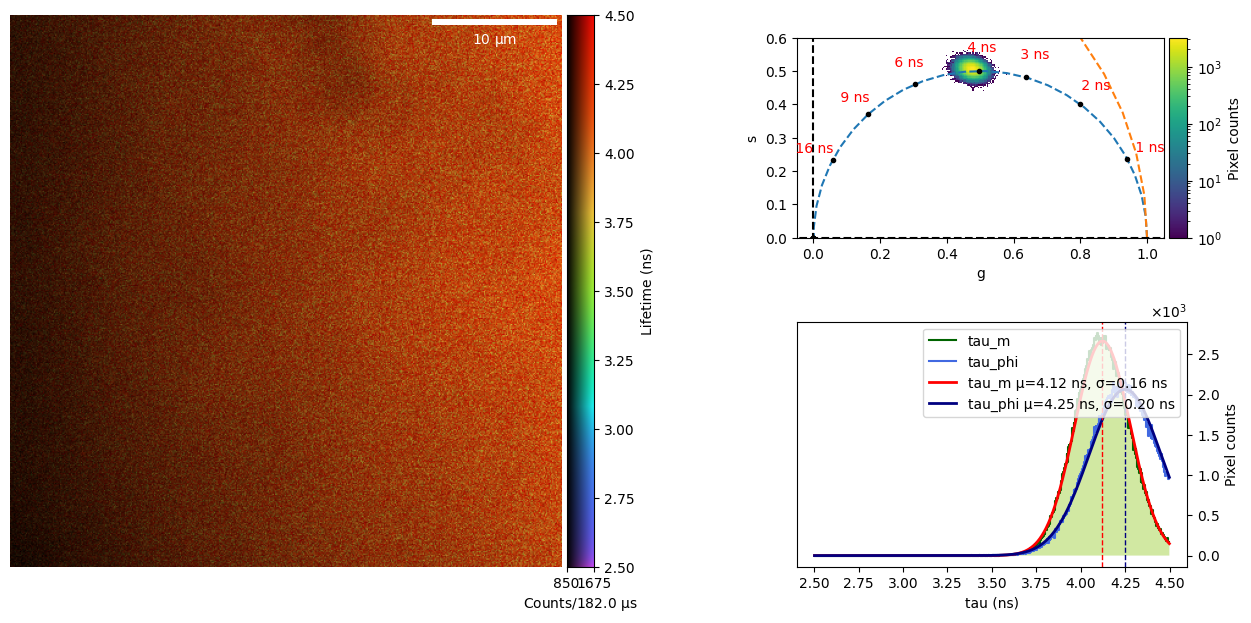

In [46]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'

upper_bound = 4.5
lower_bound = 2.5

bin_plot = 500

fig = plt.figure(figsize = (18, 12))
gs = fig.add_gridspec(4, 4)

ax1 = fig.add_subplot(gs[0:2, 0:2])


gra.show_flim(intensity_map[crop:-crop, crop:-crop], lifetime_map[crop:-crop, crop:-crop], pixel_size_x_um, pxdwelltime, lifetime_bounds = [lower_bound,upper_bound], fig = fig, ax = ax1, colormap=cmap)

ax3 = fig.add_subplot(gs[0, 2:3])
ax4 = fig.add_subplot(gs[1, 2:3])

flim.plot_phasor(thresholded_phasor_map, quadrant='first', bins_2dplot = bin_plot, cmap='viridis', dfd_freq = laser_freq_mhz*1e6,  fig = fig, ax = ax3)
# Overlay tau_m and tau_phi histograms on the same thresholded phasor pixels.
n_m, bins = np.histogram(thresholded_tau_m_map, bins=bin_plot, range=(lower_bound, upper_bound))
n_phi, _ = np.histogram(thresholded_tau_phi_map, bins=bins)
bin_centers = 0.5*(bins[:-1] + bins[1:])
ax4.plot(bin_centers, n_m, drawstyle='steps-mid', color='darkgreen', linewidth=1.5, label='tau_m')
ax4.fill_between(bin_centers, n_m, step='mid', facecolor='yellowgreen', alpha=0.45)
ax4.plot(bin_centers, n_phi, drawstyle='steps-mid', color='royalblue', linewidth=1.5, label='tau_phi')
mean_tau_m = np.nanmean(thresholded_tau_m_map)
rms_tau_m = np.nanstd(thresholded_tau_m_map)
mean_tau_phi = np.nanmean(thresholded_tau_phi_map)
rms_tau_phi = np.nanstd(thresholded_tau_phi_map)
gauss_m = np.exp(-0.5*((bin_centers - mean_tau_m)/rms_tau_m)**2)
gauss_phi = np.exp(-0.5*((bin_centers - mean_tau_phi)/rms_tau_phi)**2)
gauss_m_scaled = gauss_m * (n_m.sum()/gauss_m.sum()) if gauss_m.sum() > 0 else gauss_m
gauss_phi_scaled = gauss_phi * (n_phi.sum()/gauss_phi.sum()) if gauss_phi.sum() > 0 else gauss_phi
ax4.plot(bin_centers, gauss_m_scaled, color='red', linewidth=2, label=f'tau_m μ={mean_tau_m:.2f} ns, σ={rms_tau_m:.2f} ns')
ax4.plot(bin_centers, gauss_phi_scaled, color='navy', linewidth=2, label=f'tau_phi μ={mean_tau_phi:.2f} ns, σ={rms_tau_phi:.2f} ns')
ax4.axvline(mean_tau_m, color='red', linestyle='--', linewidth=1)
ax4.axvline(mean_tau_phi, color='navy', linestyle='--', linewidth=1)
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position("right")
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
ax4.legend(loc='upper right')
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3,3))
ax4.yaxis.set_major_formatter(sf)




## Optional: equalized FLIM rendering


The equalized FLIM plotting helpers used below are implemented in `brighteyes_flim.tools_phasor`.



/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:873: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_1731806/3487327486.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


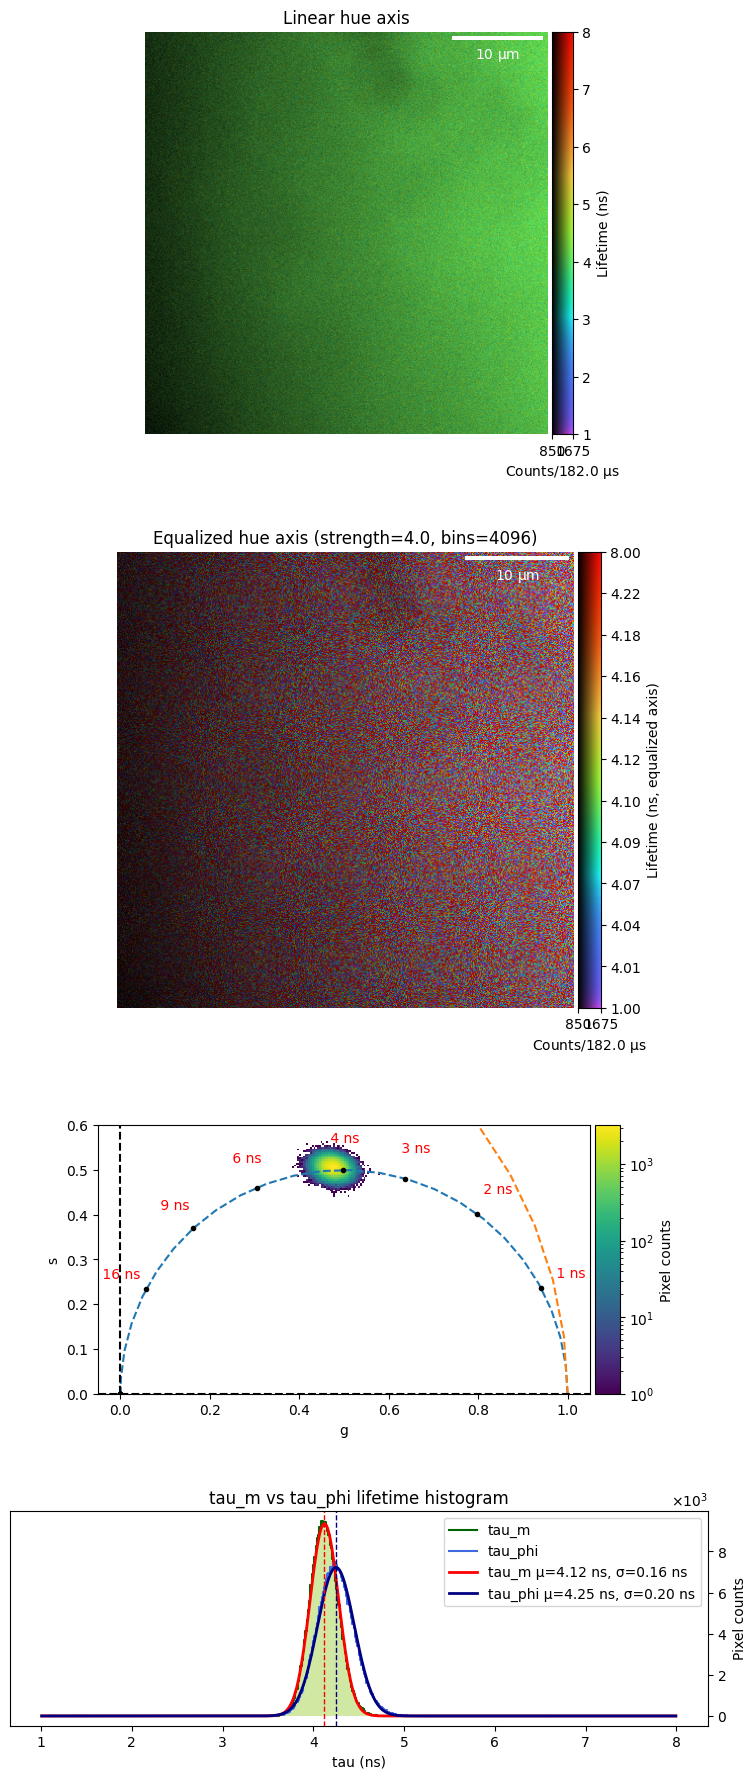

In [48]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'
equalization_strength = 4.0
equalization_bins = 4096
equalization_tick_count = 12

upper_bound = 8
lower_bound = 1.
lifetime_bounds = [lower_bound, upper_bound]

bin_plot = 500

display_intensity = intensity_map[crop:-crop, crop:-crop]
display_lifetime = lifetime_map[crop:-crop, crop:-crop]
equalization_reference = thresholded_tau_map

fig = plt.figure(figsize=(9, 22))
gs = fig.add_gridspec(4, 1, height_ratios=[1.5, 1.7, 1.0, 0.8], hspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
gra.show_flim(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax1,
    colormap=cmap,
)
ax1.set_title('Linear hue axis')

ax2 = fig.add_subplot(gs[1, 0])
flim.show_flim_equalized(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax2,
    colormap=cmap,
    equalization_reference=equalization_reference,
    equalization_strength=equalization_strength,
    equalization_bins=equalization_bins,
    colorbar_ticks=equalization_tick_count,
)
ax2.set_title(
    f'Equalized hue axis (strength={equalization_strength:.1f}, bins={equalization_bins})'
)

ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[3, 0])

flim.plot_phasor(
    thresholded_phasor_map,
    quadrant='first',
    bins_2dplot=bin_plot,
    cmap='viridis',
    dfd_freq=laser_freq_mhz * 1e6,
    fig=fig,
    ax=ax3,
)




# Histogram + Gaussian overlay for tau_m and tau_phi.
n_m, bins = np.histogram(thresholded_tau_m_map, bins=500, range=(lower_bound, upper_bound))
n_phi, _ = np.histogram(thresholded_tau_phi_map, bins=bins)
bin_centers = 0.5*(bins[:-1] + bins[1:])
ax4.plot(bin_centers, n_m, drawstyle='steps-mid', color='darkgreen', linewidth=1.5, label='tau_m')
ax4.fill_between(bin_centers, n_m, step='mid', facecolor='yellowgreen', alpha=0.45)
ax4.plot(bin_centers, n_phi, drawstyle='steps-mid', color='royalblue', linewidth=1.5, label='tau_phi')
mean_tau_m = np.nanmean(thresholded_tau_m_map)
rms_tau_m = np.nanstd(thresholded_tau_m_map)
mean_tau_phi = np.nanmean(thresholded_tau_phi_map)
rms_tau_phi = np.nanstd(thresholded_tau_phi_map)
gauss_m = np.exp(-0.5*((bin_centers - mean_tau_m)/rms_tau_m)**2)
gauss_phi = np.exp(-0.5*((bin_centers - mean_tau_phi)/rms_tau_phi)**2)
gauss_m_scaled = gauss_m * (n_m.sum()/gauss_m.sum()) if gauss_m.sum() > 0 else gauss_m
gauss_phi_scaled = gauss_phi * (n_phi.sum()/gauss_phi.sum()) if gauss_phi.sum() > 0 else gauss_phi
ax4.plot(bin_centers, gauss_m_scaled, color='red', linewidth=2, label=f'tau_m μ={mean_tau_m:.2f} ns, σ={rms_tau_m:.2f} ns')
ax4.plot(bin_centers, gauss_phi_scaled, color='navy', linewidth=2, label=f'tau_phi μ={mean_tau_phi:.2f} ns, σ={rms_tau_phi:.2f} ns')
ax4.axvline(mean_tau_m, color='red', linestyle='--', linewidth=1)
ax4.axvline(mean_tau_phi, color='navy', linestyle='--', linewidth=1)
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position('right')
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
ax4.set_title('tau_m vs tau_phi lifetime histogram')
ax4.legend(loc='upper right')
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3, 3))
ax4.yaxis.set_major_formatter(sf)
fig.tight_layout()


In [ ]:
with h5py.File(FILE_WITH_CALIBRATION,"r") as f:
    
        laser_freq_mhz = float(f["calibration/data"].attrs["laser_freq_in_mhz"]) 
        laser_period_ns = float(f["calibration/data"].attrs["laser_period_in_ns"])
        rangex = f['configurationGUI'].attrs['range_x']
        nx = f['configurationGUI'].attrs['nx']
        pixel_size_x_um= rangex / nx
        nbin = f['configurationGUI'].attrs['timebin_per_pixel']
        dt = f['configurationGUI'].attrs['time_resolution']
        pxdwelltime = dt * nbin

        print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")
    
        print(f.keys())
        data_input = f["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference

Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra', 'thumbnail']>


In [ ]:
import gc
for obj in gc.get_objects():   # Browse through ALL objects
    if isinstance(obj, h5py.File):   # Just HDF5 files
        try:
            obj.close()
        except:
            pass # Was already closed

/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/abc.py:119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return _abc_instancecheck(cls, instance)


ReferenceError: weakly-referenced object no longer exists

In [ ]:
signal =  data_input[0,0,:,:,:,:].sum(axis=-1) 
signal.shape

(1250, 1250, 81)

In [ ]:
with h5py.File("/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47_PHASOR2.h5","w") as hf:
    hf["intensity_map"] = intensity_map
    hf["real"] = np.real(phasor_map)
    hf["imag"] = np.imag(phasor_map)
    hf["signal"] = signal  # only if you want to store the raw signal too

    hf["intensity_map"].attrs["dims"] = "YX"
    hf["real"].attrs["harmonics"] = [1]
    hf["imag"].attrs["harmonics"] = [1]
    hf["signal"].attrs["dims"] = "YXH"  # only if signal.shape is (Y, X, H)

    hf.attrs["frequency"] = 40.0
    hf.attrs["samples"] = 91

In [ ]:
show_h5_structure_html(FILE_WITH_CALIBRATION)

In [ ]:
with h5py.File(FILE_WITH_CALIBRATION,"r") as f:
    
        laser_freq_mhz = float(f["calibration/data"].attrs["laser_freq_in_mhz"]) 
        laser_period_ns = float(f["calibration/data"].attrs["laser_period_in_ns"])
        rangex = f['configurationGUI'].attrs['range_x']
        nx = f['configurationGUI'].attrs['nx']
        pixel_size_x_um= rangex / nx
        nbin = f['configurationGUI'].attrs['timebin_per_pixel']
        dt = f['configurationGUI'].attrs['time_resolution']
        pxdwelltime = dt * nbin

        print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")
    
        print(f.keys())
        data_input = f["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference.
        channel_skew = f["calibration/data/channel_skew"][:]
        common_delay_in_bins = f["calibration/data/common_delay_in_bins"][:]
        irf_common_delay_realigned = f["calibration/data/irf_common_delay_realigned"][:]   

        

Using calibrated laser timing: 41.4800 MHz (24.1080 ns)
<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra']>


(81, 25)

In [ ]:

signal = irf_common_delay_realigned.sum(axis=-1)

irf = np.asarray([1])
irf = np.expand_dims(irf, axis=(0,-1))

phasor_ref = np.asarray([flim.phasor(irf_common_delay_realigned.sum(axis=-1))])
phasor_ref=np.expand_dims(phasor_ref, axis=(0,-1))

with h5py.File("/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47_PHASOR-REF.h5","w") as hf:
    hf["intensity_map"] = irf.sum(axis=-1)
    hf["real"] = np.real(phasor_ref)
    hf["imag"] = np.imag(phasor_ref)
    hf["signal"] = signal  # only if you want to store the raw signal too

    hf["intensity_map"].attrs["dims"] = "YX"
    hf["real"].attrs["harmonics"] = [1]
    hf["imag"].attrs["harmonics"] = [1]
    hf["signal"].attrs["dims"] = "YXH"  # only if signal.shape is (Y, X, H)

    hf.attrs["frequency"] = 40.0
    hf.attrs["samples"] = 91